In [2]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd

import requests
import re
from concurrent.futures import ThreadPoolExecutor

In [2]:
df = pd.DataFrame()
dir = '../01_scraper/scraped_data/'
for file in os.listdir(dir):
    if file.endswith('.csv'):
        temp = pd.read_csv(dir + file, sep=';', decimal=',')
        df = pd.concat([df, temp], ignore_index=True)
df

,Fecha,Texto
0,2021-07-06T02:54:51.000Z,EMERGENCIA: 22:53 10-8 (LLAMADO NO CLASIFICADO...
1,2021-07-06T16:06:15.000Z,"EMERGENCIA: 12:05 10-0 (LLAMADO ESTRUCTURAL), ..."
2,2021-07-07T00:22:08.000Z,EMERGENCIA: 20:21 10-8 (LLAMADO NO CLASIFICADO...
3,2021-07-07T00:26:37.000Z,"20:25, SALE B-4 A 10-8 (LLAMADO NO CLASIFICAD..."
4,2021-07-07T01:28:03.000Z,"EMERGENCIA: 21:26 10-0 (LLAMADO ESTRUCTURAL), ..."
...,...,...
9205,2026-04-16T17:39:45.000Z,10-4-1 AVENIDA ARGENTINA / JUAN DE LA CRUZ TAP...
9206,2026-04-16T17:46:30.000Z,SALE RB-6 A 10-4-1 AVENIDA ARGENTINA / JUAN DE...
9207,2026-04-16T17:49:42.000Z,SALE RX-5 A 10-4-1 AVENIDA ARGENTINA / JUAN DE...
9208,2026-04-16T23:19:32.000Z,10-3-4 PORTALES / HUALPEN RB-3 https://t.co/XL...


In [ ]:
df = pd.read_csv('compiled_scraped_data.csv', sep=';', decimal=',')
df['FECHA_DIA'] = df['Fecha'].astype(str).str[:10]
df['FECHA_HORA'] = df['Fecha'].astype(str).str[11:19]
patron = r"\b(10-\d+(?:-\d+)?)\b"
df['CODIGO_EMERGENCIA'] = df['Texto'].str.extract(patron)
df['URL'] = df['Texto'].str.extract(r'(https?://[^\s]+)')


mask_pastizal = df['Texto'].str.contains(r'PASTIZAL|FORESTAL', case=False, na=False)
mask_incendio = df['Texto'].str.contains(r'INCENDIO', case=False, na=False)

df['CODIGO_EMERGENCIA'] = np.where(
    df['CODIGO_EMERGENCIA'].notna(), df['CODIGO_EMERGENCIA'],
    np.where(mask_pastizal, '10-2-3',
    np.where(mask_incendio, '10-0-6', '0-0-0'))
)

patron = r"\b[A-Z]+-?\d+\b"  # Para códigos tipo "B5", "B-5", "RX5", "RX-5"
df['CODIGO_UNIDAD'] = df["Texto"].str.findall(patron).str.join(", ")
df

,Fecha,Texto,FECHA_DIA,FECHA_HORA,CODIGO_EMERGENCIA,URL,CODIGO_UNIDAD
0,2022-01-04T14:06:48.000Z,EMERGENCIA: 11:06 10-8 (LLAMADO NO CLASIFICADO...,2022-01-04,14:06:48,10-8,NaN,B-1
1,2022-01-04T16:04:42.000Z,"EMERGENCIA: 13:04 10-4 (RESCATE VEHICULAR), AV...",2022-01-04,16:04:42,10-4,NaN,"RB-5, B-9"
2,2022-01-04T17:40:50.000Z,EMERGENCIA: 14:40 10-2 (LLAMADO DE PASTIZALES)...,2022-01-04,17:40:50,10-2,NaN,B-4
3,2022-01-04T17:43:44.000Z,"14:43, SALE B-11 A 10-2 (LLAMADO DE PASTIZALE...",2022-01-04,17:43:44,10-2,NaN,B-11
4,2022-01-04T17:45:44.000Z,"14:45, SALE F-7 A 10-2 (LLAMADO DE PASTIZALES...",2022-01-04,17:45:44,10-2,NaN,F-7
...,...,...,...,...,...,...,...
8534,2026-04-16T17:39:45.000Z,10-4-1 AVENIDA ARGENTINA / JUAN DE LA CRUZ TAP...,2026-04-16,17:39:45,10-4-1,https://t.co/usdpl9cnYL,"RB-3, BQ-7"
8535,2026-04-16T17:46:30.000Z,SALE RB-6 A 10-4-1 AVENIDA ARGENTINA / JUAN DE...,2026-04-16,17:46:30,10-4-1,https://t.co/usdpl9cnYL,RB-6
8536,2026-04-16T17:49:42.000Z,SALE RX-5 A 10-4-1 AVENIDA ARGENTINA / JUAN DE...,2026-04-16,17:49:42,10-4-1,https://t.co/usdpl9cnYL,RX-5
8537,2026-04-16T23:19:32.000Z,10-3-4 PORTALES / HUALPEN RB-3 https://t.co/XL...,2026-04-16,23:19:32,10-3-4,https://t.co/XLloen6rGy,RB-3


In [4]:
df['FECHA_DT'] = pd.to_datetime(df['Fecha'])
df['MONTH_NAME'] = pd.to_datetime(df['FECHA_DT']).dt.month_name()
df['DAY'] = pd.to_datetime(df['FECHA_DT']).dt.day
df['DAY_NAME'] = pd.to_datetime(df['FECHA_DT']).dt.day_name()
df['FECHA_HORA_NUM'] = df['FECHA_DT'].dt.hour
df

,Fecha,Texto,FECHA_DIA,FECHA_HORA,CODIGO_EMERGENCIA,URL,CODIGO_UNIDAD,FECHA_DT,MONTH_NAME,DAY,DAY_NAME,FECHA_HORA_NUM
0,2022-01-04T14:06:48.000Z,EMERGENCIA: 11:06 10-8 (LLAMADO NO CLASIFICADO...,2022-01-04,14:06:48,10-8,NaN,B-1,2022-01-04 14:06:48+00:00,January,4,Tuesday,14
1,2022-01-04T16:04:42.000Z,"EMERGENCIA: 13:04 10-4 (RESCATE VEHICULAR), AV...",2022-01-04,16:04:42,10-4,NaN,"RB-5, B-9",2022-01-04 16:04:42+00:00,January,4,Tuesday,16
2,2022-01-04T17:40:50.000Z,EMERGENCIA: 14:40 10-2 (LLAMADO DE PASTIZALES)...,2022-01-04,17:40:50,10-2,NaN,B-4,2022-01-04 17:40:50+00:00,January,4,Tuesday,17
3,2022-01-04T17:43:44.000Z,"14:43, SALE B-11 A 10-2 (LLAMADO DE PASTIZALE...",2022-01-04,17:43:44,10-2,NaN,B-11,2022-01-04 17:43:44+00:00,January,4,Tuesday,17
4,2022-01-04T17:45:44.000Z,"14:45, SALE F-7 A 10-2 (LLAMADO DE PASTIZALES...",2022-01-04,17:45:44,10-2,NaN,F-7,2022-01-04 17:45:44+00:00,January,4,Tuesday,17
...,...,...,...,...,...,...,...,...,...,...,...,...
8534,2026-04-16T17:39:45.000Z,10-4-1 AVENIDA ARGENTINA / JUAN DE LA CRUZ TAP...,2026-04-16,17:39:45,10-4-1,https://t.co/usdpl9cnYL,"RB-3, BQ-7",2026-04-16 17:39:45+00:00,April,16,Thursday,17
8535,2026-04-16T17:46:30.000Z,SALE RB-6 A 10-4-1 AVENIDA ARGENTINA / JUAN DE...,2026-04-16,17:46:30,10-4-1,https://t.co/usdpl9cnYL,RB-6,2026-04-16 17:46:30+00:00,April,16,Thursday,17
8536,2026-04-16T17:49:42.000Z,SALE RX-5 A 10-4-1 AVENIDA ARGENTINA / JUAN DE...,2026-04-16,17:49:42,10-4-1,https://t.co/usdpl9cnYL,RX-5,2026-04-16 17:49:42+00:00,April,16,Thursday,17
8537,2026-04-16T23:19:32.000Z,10-3-4 PORTALES / HUALPEN RB-3 https://t.co/XL...,2026-04-16,23:19:32,10-3-4,https://t.co/XLloen6rGy,RB-3,2026-04-16 23:19:32+00:00,April,16,Thursday,23


In [5]:
codigos = pd.read_excel('Clave_CBT.xlsx')
df1 = pd.merge(df, codigos, how='left', on='CODIGO_EMERGENCIA')
df1 = df1.drop(columns='DESCRIPCION')
df1

,Fecha,Texto,FECHA_DIA,FECHA_HORA,CODIGO_EMERGENCIA,URL,CODIGO_UNIDAD,FECHA_DT,MONTH_NAME,DAY,DAY_NAME,FECHA_HORA_NUM,CATEGORIA_EMERGENCIA
0,2022-01-04T14:06:48.000Z,EMERGENCIA: 11:06 10-8 (LLAMADO NO CLASIFICADO...,2022-01-04,14:06:48,10-8,NaN,B-1,2022-01-04 14:06:48+00:00,January,4,Tuesday,14,LLAMADOS SIN SUBCLASIFICACIÓN
1,2022-01-04T16:04:42.000Z,"EMERGENCIA: 13:04 10-4 (RESCATE VEHICULAR), AV...",2022-01-04,16:04:42,10-4,NaN,"RB-5, B-9",2022-01-04 16:04:42+00:00,January,4,Tuesday,16,RESCATE VEHICULAR
2,2022-01-04T17:40:50.000Z,EMERGENCIA: 14:40 10-2 (LLAMADO DE PASTIZALES)...,2022-01-04,17:40:50,10-2,NaN,B-4,2022-01-04 17:40:50+00:00,January,4,Tuesday,17,INCENDIO PASTIZAL O FORESTAL
3,2022-01-04T17:43:44.000Z,"14:43, SALE B-11 A 10-2 (LLAMADO DE PASTIZALE...",2022-01-04,17:43:44,10-2,NaN,B-11,2022-01-04 17:43:44+00:00,January,4,Tuesday,17,INCENDIO PASTIZAL O FORESTAL
4,2022-01-04T17:45:44.000Z,"14:45, SALE F-7 A 10-2 (LLAMADO DE PASTIZALES...",2022-01-04,17:45:44,10-2,NaN,F-7,2022-01-04 17:45:44+00:00,January,4,Tuesday,17,INCENDIO PASTIZAL O FORESTAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10489,2026-04-16T17:39:45.000Z,10-4-1 AVENIDA ARGENTINA / JUAN DE LA CRUZ TAP...,2026-04-16,17:39:45,10-4-1,https://t.co/usdpl9cnYL,"RB-3, BQ-7",2026-04-16 17:39:45+00:00,April,16,Thursday,17,RESCATE VEHICULAR
10490,2026-04-16T17:46:30.000Z,SALE RB-6 A 10-4-1 AVENIDA ARGENTINA / JUAN DE...,2026-04-16,17:46:30,10-4-1,https://t.co/usdpl9cnYL,RB-6,2026-04-16 17:46:30+00:00,April,16,Thursday,17,RESCATE VEHICULAR
10491,2026-04-16T17:49:42.000Z,SALE RX-5 A 10-4-1 AVENIDA ARGENTINA / JUAN DE...,2026-04-16,17:49:42,10-4-1,https://t.co/usdpl9cnYL,RX-5,2026-04-16 17:49:42+00:00,April,16,Thursday,17,RESCATE VEHICULAR
10492,2026-04-16T23:19:32.000Z,10-3-4 PORTALES / HUALPEN RB-3 https://t.co/XL...,2026-04-16,23:19:32,10-3-4,https://t.co/XLloen6rGy,RB-3,2026-04-16 23:19:32+00:00,April,16,Thursday,23,RESCATE DE PERSONAS


In [6]:
df1.to_csv('tweets_procesados.csv', index=False, sep=';', decimal=',')

In [ ]:
import pandas as pd


def obtener_coordenadas(url):
    """Sigue las redirecciones y extrae (lat, lon) de la URL final de Google Maps"""
    if pd.isna(url):
        return (None, None)
    
    try:
        # User-Agent falso para evitar que Google rechace la conexión por ser un bot
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        
        # Sigue las redirecciones hasta llegar a la URL final
        res = requests.get(url, headers=headers, allow_redirects=True, timeout=10)
        url_final = res.url
        
        # Las coordenadas en Google Maps suelen venir como: 
        # .../@-36.82,-73.04... o ...?q=-36.82,-73.04... o ...&ll=-36.82,-73.04...
        patron = r'(?:@|q=|ll=)(-?\d+\.\d+),(-?\d+\.\d+)'
        match = re.search(patron, url_final)
        
        if match:
            return (float(match.group(1)), float(match.group(2)))
        return (None, None)
        
    except Exception as e:
        # Maneja timeouts o errores de conexión silenciosamente
        return (None, None)





In [13]:
# Ejecución concurrente para no bloquear el proceso (Ajusta max_workers según tu CPU/Red)
with ThreadPoolExecutor(max_workers=10) as executor:
    # Mapea la función a la columna 'url' en paralelo
    resultados = list(executor.map(obtener_coordenadas, df1['URL']))

# Desempaqueta la lista de tuplas (lat, lon) en dos nuevas columnas
df1[['latitud_x', 'longitud_y']] = pd.DataFrame(resultados, index=df1.index)
df1

,Fecha,Texto,FECHA_DIA,FECHA_HORA,CODIGO_EMERGENCIA,URL,CODIGO_UNIDAD,FECHA_DT,MONTH_NAME,DAY,DAY_NAME,FECHA_HORA_NUM,CATEGORIA_EMERGENCIA,latitud_x,longitud_y
0,2022-01-04T14:06:48.000Z,EMERGENCIA: 11:06 10-8 (LLAMADO NO CLASIFICADO...,2022-01-04,14:06:48,10-8,NaN,B-1,2022-01-04 14:06:48+00:00,January,4,Tuesday,14,LLAMADOS SIN SUBCLASIFICACIÓN,NaN,NaN
1,2022-01-04T16:04:42.000Z,"EMERGENCIA: 13:04 10-4 (RESCATE VEHICULAR), AV...",2022-01-04,16:04:42,10-4,NaN,"RB-5, B-9",2022-01-04 16:04:42+00:00,January,4,Tuesday,16,RESCATE VEHICULAR,NaN,NaN
2,2022-01-04T17:40:50.000Z,EMERGENCIA: 14:40 10-2 (LLAMADO DE PASTIZALES)...,2022-01-04,17:40:50,10-2,NaN,B-4,2022-01-04 17:40:50+00:00,January,4,Tuesday,17,INCENDIO PASTIZAL O FORESTAL,NaN,NaN
3,2022-01-04T17:43:44.000Z,"14:43, SALE B-11 A 10-2 (LLAMADO DE PASTIZALE...",2022-01-04,17:43:44,10-2,NaN,B-11,2022-01-04 17:43:44+00:00,January,4,Tuesday,17,INCENDIO PASTIZAL O FORESTAL,NaN,NaN
4,2022-01-04T17:45:44.000Z,"14:45, SALE F-7 A 10-2 (LLAMADO DE PASTIZALES...",2022-01-04,17:45:44,10-2,NaN,F-7,2022-01-04 17:45:44+00:00,January,4,Tuesday,17,INCENDIO PASTIZAL O FORESTAL,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10489,2026-04-16T17:39:45.000Z,10-4-1 AVENIDA ARGENTINA / JUAN DE LA CRUZ TAP...,2026-04-16,17:39:45,10-4-1,https://t.co/usdpl9cnYL,"RB-3, BQ-7",2026-04-16 17:39:45+00:00,April,16,Thursday,17,RESCATE VEHICULAR,-36.721710,-73.122432
10490,2026-04-16T17:46:30.000Z,SALE RB-6 A 10-4-1 AVENIDA ARGENTINA / JUAN DE...,2026-04-16,17:46:30,10-4-1,https://t.co/usdpl9cnYL,RB-6,2026-04-16 17:46:30+00:00,April,16,Thursday,17,RESCATE VEHICULAR,-36.721710,-73.122432
10491,2026-04-16T17:49:42.000Z,SALE RX-5 A 10-4-1 AVENIDA ARGENTINA / JUAN DE...,2026-04-16,17:49:42,10-4-1,https://t.co/usdpl9cnYL,RX-5,2026-04-16 17:49:42+00:00,April,16,Thursday,17,RESCATE VEHICULAR,-36.721710,-73.122432
10492,2026-04-16T23:19:32.000Z,10-3-4 PORTALES / HUALPEN RB-3 https://t.co/XL...,2026-04-16,23:19:32,10-3-4,https://t.co/XLloen6rGy,RB-3,2026-04-16 23:19:32+00:00,April,16,Thursday,23,RESCATE DE PERSONAS,-36.733166,-73.111053


In [ ]:
from pyproj import Transformer
transformador = Transformer.from_crs("EPSG:4326", "EPSG:32718", always_xy=True)

# Pasamos las columnas completas directamente al transformador
# Nota: Pasamos la longitud primero (X) y la latitud después (Y)
df1['utm_x_32718'], df1['utm_y_32718'] = transformador.transform(df1['longitud_y'].values, df1['latitud_x'].values)

,Fecha,Texto,FECHA_DIA,FECHA_HORA,CODIGO_EMERGENCIA,URL,CODIGO_UNIDAD,FECHA_DT,MONTH_NAME,DAY,DAY_NAME,FECHA_HORA_NUM,CATEGORIA_EMERGENCIA,latitud_x,longitud_y,utm_x_32718,utm_y_32718
0,2022-01-04T14:06:48.000Z,EMERGENCIA: 11:06 10-8 (LLAMADO NO CLASIFICADO...,2022-01-04,14:06:48,10-8,NaN,B-1,2022-01-04 14:06:48+00:00,January,4,Tuesday,14,LLAMADOS SIN SUBCLASIFICACIÓN,NaN,NaN,NaN,NaN
1,2022-01-04T16:04:42.000Z,"EMERGENCIA: 13:04 10-4 (RESCATE VEHICULAR), AV...",2022-01-04,16:04:42,10-4,NaN,"RB-5, B-9",2022-01-04 16:04:42+00:00,January,4,Tuesday,16,RESCATE VEHICULAR,NaN,NaN,NaN,NaN
2,2022-01-04T17:40:50.000Z,EMERGENCIA: 14:40 10-2 (LLAMADO DE PASTIZALES)...,2022-01-04,17:40:50,10-2,NaN,B-4,2022-01-04 17:40:50+00:00,January,4,Tuesday,17,INCENDIO PASTIZAL O FORESTAL,NaN,NaN,NaN,NaN
3,2022-01-04T17:43:44.000Z,"14:43, SALE B-11 A 10-2 (LLAMADO DE PASTIZALE...",2022-01-04,17:43:44,10-2,NaN,B-11,2022-01-04 17:43:44+00:00,January,4,Tuesday,17,INCENDIO PASTIZAL O FORESTAL,NaN,NaN,NaN,NaN
4,2022-01-04T17:45:44.000Z,"14:45, SALE F-7 A 10-2 (LLAMADO DE PASTIZALES...",2022-01-04,17:45:44,10-2,NaN,F-7,2022-01-04 17:45:44+00:00,January,4,Tuesday,17,INCENDIO PASTIZAL O FORESTAL,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10489,2026-04-16T17:39:45.000Z,10-4-1 AVENIDA ARGENTINA / JUAN DE LA CRUZ TAP...,2026-04-16,17:39:45,10-4-1,https://t.co/usdpl9cnYL,"RB-3, BQ-7",2026-04-16 17:39:45+00:00,April,16,Thursday,17,RESCATE VEHICULAR,-36.721710,-73.122432,667674.079374,5.934355e+06
10490,2026-04-16T17:46:30.000Z,SALE RB-6 A 10-4-1 AVENIDA ARGENTINA / JUAN DE...,2026-04-16,17:46:30,10-4-1,https://t.co/usdpl9cnYL,RB-6,2026-04-16 17:46:30+00:00,April,16,Thursday,17,RESCATE VEHICULAR,-36.721710,-73.122432,667674.079374,5.934355e+06
10491,2026-04-16T17:49:42.000Z,SALE RX-5 A 10-4-1 AVENIDA ARGENTINA / JUAN DE...,2026-04-16,17:49:42,10-4-1,https://t.co/usdpl9cnYL,RX-5,2026-04-16 17:49:42+00:00,April,16,Thursday,17,RESCATE VEHICULAR,-36.721710,-73.122432,667674.079374,5.934355e+06
10492,2026-04-16T23:19:32.000Z,10-3-4 PORTALES / HUALPEN RB-3 https://t.co/XL...,2026-04-16,23:19:32,10-3-4,https://t.co/XLloen6rGy,RB-3,2026-04-16 23:19:32+00:00,April,16,Thursday,23,RESCATE DE PERSONAS,-36.733166,-73.111053,668665.316723,5.933065e+06


In [17]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(df1, geometry=gpd.points_from_xy(df1['longitud_y'], df1['latitud_x']),
    crs="EPSG:4326" # Declaramos explícitamente el sistema de origen
)
gdf_utm = gdf.to_crs("EPSG:32718")
gdf_utm

,Fecha,Texto,FECHA_DIA,FECHA_HORA,CODIGO_EMERGENCIA,URL,CODIGO_UNIDAD,FECHA_DT,MONTH_NAME,DAY,DAY_NAME,FECHA_HORA_NUM,CATEGORIA_EMERGENCIA,latitud_x,longitud_y,utm_x_32718,utm_y_32718,geometry
0,2022-01-04T14:06:48.000Z,EMERGENCIA: 11:06 10-8 (LLAMADO NO CLASIFICADO...,2022-01-04,14:06:48,10-8,NaN,B-1,2022-01-04 14:06:48+00:00,January,4,Tuesday,14,LLAMADOS SIN SUBCLASIFICACIÓN,NaN,NaN,NaN,NaN,POINT (NaN NaN)
1,2022-01-04T16:04:42.000Z,"EMERGENCIA: 13:04 10-4 (RESCATE VEHICULAR), AV...",2022-01-04,16:04:42,10-4,NaN,"RB-5, B-9",2022-01-04 16:04:42+00:00,January,4,Tuesday,16,RESCATE VEHICULAR,NaN,NaN,NaN,NaN,POINT (NaN NaN)
2,2022-01-04T17:40:50.000Z,EMERGENCIA: 14:40 10-2 (LLAMADO DE PASTIZALES)...,2022-01-04,17:40:50,10-2,NaN,B-4,2022-01-04 17:40:50+00:00,January,4,Tuesday,17,INCENDIO PASTIZAL O FORESTAL,NaN,NaN,NaN,NaN,POINT (NaN NaN)
3,2022-01-04T17:43:44.000Z,"14:43, SALE B-11 A 10-2 (LLAMADO DE PASTIZALE...",2022-01-04,17:43:44,10-2,NaN,B-11,2022-01-04 17:43:44+00:00,January,4,Tuesday,17,INCENDIO PASTIZAL O FORESTAL,NaN,NaN,NaN,NaN,POINT (NaN NaN)
4,2022-01-04T17:45:44.000Z,"14:45, SALE F-7 A 10-2 (LLAMADO DE PASTIZALES...",2022-01-04,17:45:44,10-2,NaN,F-7,2022-01-04 17:45:44+00:00,January,4,Tuesday,17,INCENDIO PASTIZAL O FORESTAL,NaN,NaN,NaN,NaN,POINT (NaN NaN)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10489,2026-04-16T17:39:45.000Z,10-4-1 AVENIDA ARGENTINA / JUAN DE LA CRUZ TAP...,2026-04-16,17:39:45,10-4-1,https://t.co/usdpl9cnYL,"RB-3, BQ-7",2026-04-16 17:39:45+00:00,April,16,Thursday,17,RESCATE VEHICULAR,-36.721710,-73.122432,667674.079374,5.934355e+06,POINT (667674.079 5934355.435)
10490,2026-04-16T17:46:30.000Z,SALE RB-6 A 10-4-1 AVENIDA ARGENTINA / JUAN DE...,2026-04-16,17:46:30,10-4-1,https://t.co/usdpl9cnYL,RB-6,2026-04-16 17:46:30+00:00,April,16,Thursday,17,RESCATE VEHICULAR,-36.721710,-73.122432,667674.079374,5.934355e+06,POINT (667674.079 5934355.435)
10491,2026-04-16T17:49:42.000Z,SALE RX-5 A 10-4-1 AVENIDA ARGENTINA / JUAN DE...,2026-04-16,17:49:42,10-4-1,https://t.co/usdpl9cnYL,RX-5,2026-04-16 17:49:42+00:00,April,16,Thursday,17,RESCATE VEHICULAR,-36.721710,-73.122432,667674.079374,5.934355e+06,POINT (667674.079 5934355.435)
10492,2026-04-16T23:19:32.000Z,10-3-4 PORTALES / HUALPEN RB-3 https://t.co/XL...,2026-04-16,23:19:32,10-3-4,https://t.co/XLloen6rGy,RB-3,2026-04-16 23:19:32+00:00,April,16,Thursday,23,RESCATE DE PERSONAS,-36.733166,-73.111053,668665.316723,5.933065e+06,POINT (668665.317 5933064.529)


In [20]:
gdf_utm.to_file('puntos_emergencias.gpkg', driver='GPKG')

In [7]:
temp1 = df1[['MONTH_NAME']].drop_duplicates()
temp2 = df1[['DAY_NAME']].drop_duplicates()
temp3 = df1[['CATEGORIA_EMERGENCIA']].drop_duplicates()

temp4 = pd.merge(temp1, temp2, how='cross')
temp4 = pd.merge(temp4, temp3, how='cross')
temp4['EVENTOS'] = 0

df2 = df1.copy()
df2['EVENTOS'] = 1
df2 = df2.groupby(['MONTH_NAME', 'DAY_NAME', 'CATEGORIA_EMERGENCIA'], as_index=False).sum()
df2

TypeError: datetime64 type does not support sum operations

In [ ]:
import requests
df_final = df1.copy()

# 1. Configurar coordenadas y fechas
lat, lon = -33.0472, -71.6127 # Coordenadas de Valparaíso
fecha_inicio = df_final['FECHA_DIA'].min()
fecha_fin = df_final['FECHA_DIA'].max()
print(f"Descargando clima desde {fecha_inicio} hasta {fecha_fin}...")
# Parámetros extendidos para mejor precisión
url = (f"https://archive-api.open-meteo.com/v1/archive?"
       f"latitude={lat}&longitude={lon}&"
       f"start_date={fecha_inicio}&end_date={fecha_fin}&"
       f"daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
       f"relative_humidity_2m_max,relative_humidity_2m_min,relative_humidity_2m_mean,"
       f"wind_speed_10m_max,wind_speed_10m_mean,"
       f"precipitation_sum&"
       f"timezone=America%2FSantiago")
response = requests.get(url)
data_raw = response.json()
# Crear el DataFrame con los nombres claros
df_clima = pd.DataFrame(data_raw['daily'])
df_clima.columns = [
    'FECHA_DIA', 
    'TEMP_MAX', 'TEMP_MIN', 'TEMP_MEDIA',
    'HUM_MAX', 'HUM_MIN', 'HUM_MEDIA',
    'VIENTO_MAX', 'VIENTO_MEDIO',
    'LLUVIA'
]
# 4. Unir el Clima con tu DataFrame de Emergencias
# Aseguramos que ambas columnas sean string para el cruce
df_clima['FECHA_DIA'] = df_clima['FECHA_DIA'].astype(str)
df_final['FECHA_DIA'] = df_final['FECHA_DIA'].astype(str)
df_consolidado = pd.merge(df_final, df_clima, on='FECHA_DIA', how='left')
print("¡Datos climáticos integrados con éxito!")
df_consolidado.head()

Descargando clima desde 2022-01-04 hasta 2026-04-17...
¡Datos climáticos integrados con éxito!


,Fecha,Texto,FECHA_DIA,FECHA_HORA,CODIGO_EMERGENCIA,CODIGO_UNIDAD,FECHA_DT,MONTH_NAME,DAY,DAY_NAME,...,CATEGORIA_EMERGENCIA,TEMP_MAX,TEMP_MIN,TEMP_MEDIA,HUM_MAX,HUM_MIN,HUM_MEDIA,VIENTO_MAX,VIENTO_MEDIO,LLUVIA
0,2022-01-04T14:06:48.000Z,EMERGENCIA: 11:06 10-8 (LLAMADO NO CLASIFICADO...,2022-01-04,14:06:48,10-8,B-1,2022-01-04 14:06:48+00:00,January,4,Tuesday,...,LLAMADOS SIN SUBCLASIFICACIÓN,21.5,15.2,17.8,100,65,82,32.4,24.8,0.0
1,2022-01-04T16:04:42.000Z,"EMERGENCIA: 13:04 10-4 (RESCATE VEHICULAR), AV...",2022-01-04,16:04:42,10-4,"RB-5, B-9",2022-01-04 16:04:42+00:00,January,4,Tuesday,...,RESCATE VEHICULAR,21.5,15.2,17.8,100,65,82,32.4,24.8,0.0
2,2022-01-04T17:40:50.000Z,EMERGENCIA: 14:40 10-2 (LLAMADO DE PASTIZALES)...,2022-01-04,17:40:50,10-2,B-4,2022-01-04 17:40:50+00:00,January,4,Tuesday,...,INCENDIO PASTIZAL O FORESTAL,21.5,15.2,17.8,100,65,82,32.4,24.8,0.0
3,2022-01-04T17:43:44.000Z,"14:43, SALE B-11 A 10-2 (LLAMADO DE PASTIZALE...",2022-01-04,17:43:44,10-2,B-11,2022-01-04 17:43:44+00:00,January,4,Tuesday,...,INCENDIO PASTIZAL O FORESTAL,21.5,15.2,17.8,100,65,82,32.4,24.8,0.0
4,2022-01-04T17:45:44.000Z,"14:45, SALE F-7 A 10-2 (LLAMADO DE PASTIZALES...",2022-01-04,17:45:44,10-2,F-7,2022-01-04 17:45:44+00:00,January,4,Tuesday,...,INCENDIO PASTIZAL O FORESTAL,21.5,15.2,17.8,100,65,82,32.4,24.8,0.0


In [ ]:
df_consolidado.columns

Index(['Fecha', 'Texto', 'FECHA_DIA', 'FECHA_HORA', 'CODIGO_EMERGENCIA',
       'CODIGO_UNIDAD', 'FECHA_DT', 'MONTH_NAME', 'DAY', 'DAY_NAME',
       'FECHA_HORA_NUM', 'CATEGORIA_EMERGENCIA', 'TEMP_MAX', 'TEMP_MIN',
       'TEMP_MEDIA', 'HUM_MAX', 'HUM_MIN', 'HUM_MEDIA', 'VIENTO_MAX',
       'VIENTO_MEDIO', 'LLUVIA'],
      dtype='object')

In [ ]:
df2 = df_consolidado.copy()
df2 = df2[['MONTH_NAME', 'DAY_NAME', 'CATEGORIA_EMERGENCIA', 'TEMP_MAX', 'TEMP_MIN', 'TEMP_MEDIA', 'HUM_MAX', 'HUM_MIN', 'HUM_MEDIA', 'VIENTO_MAX', 'VIENTO_MEDIO', 'LLUVIA']]
df2['EVENTOS'] = 1
df2 = df2.groupby(['MONTH_NAME', 'DAY_NAME', 'CATEGORIA_EMERGENCIA', 'TEMP_MAX', 'TEMP_MIN', 'TEMP_MEDIA', 'HUM_MAX', 'HUM_MIN', 'HUM_MEDIA', 'VIENTO_MAX', 'VIENTO_MEDIO', 'LLUVIA'], as_index=False).sum()
df2

,MONTH_NAME,DAY_NAME,CATEGORIA_EMERGENCIA,TEMP_MAX,TEMP_MIN,TEMP_MEDIA,HUM_MAX,HUM_MIN,HUM_MEDIA,VIENTO_MAX,VIENTO_MEDIO,LLUVIA,EVENTOS
0,April,Friday,EMANACIÓN DE GASES,16.1,12.3,13.6,100,76,92,21.6,13.4,0.0,1
1,April,Friday,EMANACIÓN DE GASES,17.1,12.4,14.1,100,65,85,14.6,6.8,0.0,1
2,April,Friday,EMANACIÓN DE GASES,17.4,10.9,13.8,92,65,81,10.2,6.4,1.7,1
3,April,Friday,EMANACIÓN DE GASES,17.8,13.5,15.2,96,74,86,16.6,11.8,0.0,1
4,April,Friday,EMANACIÓN DE GASES,18.2,11.9,14.5,81,49,69,27.2,22.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4130,September,Wednesday,RESCATE VEHICULAR,16.2,9.0,12.1,86,59,74,32.1,24.1,0.0,2
4131,September,Wednesday,RESCATE VEHICULAR,16.6,7.4,11.7,87,69,78,33.6,24.7,0.0,3
4132,September,Wednesday,RESCATE VEHICULAR,17.5,10.1,13.2,94,75,84,27.2,17.1,0.0,2
4133,September,Wednesday,RESCATE VEHICULAR,19.7,11.0,15.2,90,67,79,23.0,14.4,0.3,2


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Preparar las características (X) y el objetivo (y)
# Convertimos los nombres a números (One-Hot Encoding)
X = pd.get_dummies(df2[['MONTH_NAME', 'DAY_NAME', 'CATEGORIA_EMERGENCIA', 'TEMP_MAX', 'TEMP_MIN', 'TEMP_MEDIA', 'HUM_MAX', 'HUM_MIN', 'HUM_MEDIA', 'VIENTO_MAX', 'VIENTO_MEDIO', 'LLUVIA']], drop_first=True)
y = df2['EVENTOS']
# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 3. Entrenar un Regresor (RandomForestRegressor es genial para cantidades)
oracle_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
oracle_regressor.fit(X_train, y_train)
# 4. Evaluación del Oráculo
y_pred = oracle_regressor.predict(X_test)
print(f"Error Medio Absoluto: {mean_absolute_error(y_test, y_pred):.2f} EVENTOS")
print(f"Precisión del modelo (R2): {r2_score(y_test, y_pred):.2%}")

# --- EJEMPLO DE PREDICCIÓN ---
# Esto es para que tú le preguntes al oráculo
import numpy as np
sample_idx = 0
pred_val = oracle_regressor.predict(X_test.iloc[[sample_idx]])
real_val = y_test.iloc[sample_idx]
print(f"\nPredicción ejemplo: {pred_val[0]:.1f} EVENTOS")
print(f"Realidad: {real_val} EVENTOS")

Error Medio Absoluto: 1.86 EVENTOS
Precisión del modelo (R2): -2.39%

Predicción ejemplo: 1.6 EVENTOS
Realidad: 1 EVENTOS


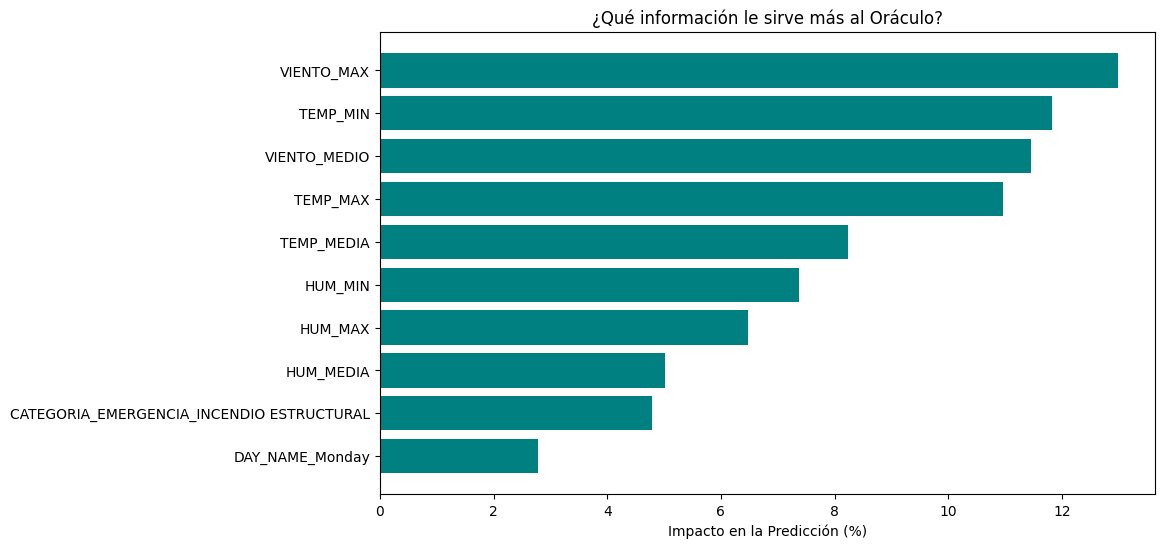

                                             Variable  Aporte (%)
6                                          VIENTO_MAX   12.984130
1                                            TEMP_MIN   11.817976
7                                        VIENTO_MEDIO   11.450994
0                                            TEMP_MAX   10.956756
2                                          TEMP_MEDIA    8.226934
4                                             HUM_MIN    7.367039
3                                             HUM_MAX    6.485083
5                                           HUM_MEDIA    5.008072
28          CATEGORIA_EMERGENCIA_INCENDIO ESTRUCTURAL    4.782414
20                                    DAY_NAME_Monday    2.789857
22                                    DAY_NAME_Sunday    2.234105
29  CATEGORIA_EMERGENCIA_INCENDIO PASTIZAL O FORESTAL    1.973073
11                                MONTH_NAME_February    1.935116
8                                              LLUVIA    1.567246
23        

In [ ]:
import matplotlib.pyplot as plt
# 1. Extraer las importancias del modelo
importancias = oracle_regressor.feature_importances_
nombres_variables = X.columns
# 2. Crearlo en un DataFrame para ordenar y limpiar
df_importancia = pd.DataFrame({
    'Variable': nombres_variables, 
    'Aporte (%)': importancias * 100
}).sort_values(by='Aporte (%)', ascending=False)
# 3. Graficar los 10 que más aportan
plt.figure(figsize=(10, 6))
top_10 = df_importancia.head(10)
plt.barh(top_10['Variable'], top_10['Aporte (%)'], color='teal')
plt.xlabel('Impacto en la Predicción (%)')
plt.title('¿Qué información le sirve más al Oráculo?')
plt.gca().invert_yaxis() # Para que el más importante salga arriba
plt.show()
# También te lo imprimo por si no tienes matplotlib a mano
print(df_importancia.head(15))